<h2>Load in Dataset</h2>

In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import Fido, attrs as a
from astropy import units as u
from astropy.coordinates import SkyCoord
import sunpy_soar
from glob import glob
from IPython.display import HTML
from astropy.io import fits
from astropy.time import Time
from datetime import datetime
#from pastamarkers import pasta, salsa
from stixpy.product import Product
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
import scipy

In [3]:
plt.close('all')

In [4]:
short_exposure_images = glob(r'C:\python_code\hrishort\*.fits')

In [5]:
initial_map = sunpy.map.Map(short_exposure_images[216])

In [6]:
tr_x=3200
tr_y=-550
bl_x=3000
bl_y=-800

In [7]:
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=initial_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=initial_map.coordinate_frame)
short_exposure_map_seq = initial_map.submap(bottom_left=bottom_left, top_right=top_right)
#short_exposure_map_seq.quicklook()

In [8]:
second_map = sunpy.map.Map(short_exposure_images[217])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=second_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=second_map.coordinate_frame)
second_map_crop = second_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map([short_exposure_map_seq, second_map_crop], sequence = True)
third_map = sunpy.map.Map(short_exposure_images[218])
top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=third_map.coordinate_frame)
bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=third_map.coordinate_frame)
third_map_crop = third_map.submap(bottom_left=bottom_left, top_right=top_right)
short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [third_map_crop], sequence = True)

In [9]:
for i in range(65):
    next_map = sunpy.map.Map(short_exposure_images[217+i])
    top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=next_map.coordinate_frame)
    bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=next_map.coordinate_frame)
    next_map_crop = next_map.submap(bottom_left=bottom_left, top_right=top_right)
    short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [next_map_crop], sequence = True)

<h2>Mask dataset</h2>

In [10]:
unmasked_map_seq = short_exposure_map_seq

In [11]:
max = np.zeros(68)
for i in range(68):
    max[i] = (unmasked_map_seq[i]).max()

<h3>3% Threshold</h3>

In [12]:
# threshold = 0.03*max.max()
# initial_masked_3 = short_exposure_map_seq[0]
# xdim = int(initial_masked_3.dimensions[0].value)
# ydim = int(initial_masked_3.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_3.data[i,j] < threshold:
#             initial_masked_3.data[i,j] = 0

In [13]:
# second_masked_3 = short_exposure_map_seq[1]
# xdim = int(second_masked_3.dimensions[0].value)
# ydim = int(second_masked_3.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_3.data[i,j] < threshold:
#             second_masked_3.data[i,j] = 0

In [14]:
# masked_map_seq_3 = sunpy.map.Map([initial_masked_3, second_masked_3], sequence = True)

In [15]:
# for n in range(65):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_3 = sunpy.map.Map(masked_map_seq_3.maps + [next_map], sequence = True)

<h3>10% Threshold</h3>

In [16]:
# threshold = 0.1*max.max()
# initial_masked_10 = short_exposure_map_seq[0]
# xdim = int(initial_masked_10.dimensions[0].value)
# ydim = int(initial_masked_10.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_10.data[i,j] < threshold:
#             initial_masked_10.data[i,j] = 0

In [17]:
# second_masked_10 = short_exposure_map_seq[1]
# xdim = int(second_masked_10.dimensions[0].value)
# ydim = int(second_masked_10.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_10.data[i,j] < threshold:
#             second_masked_10.data[i,j] = 0

In [18]:
# masked_map_seq_10 = sunpy.map.Map([initial_masked_10, second_masked_10], sequence = True)

In [19]:
# for n in range(65):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_10 = sunpy.map.Map(masked_map_seq_10.maps + [next_map], sequence = True)

<h3>20% Threshold</h3>

In [20]:
# threshold = 0.2*max.max()
# initial_masked_20 = short_exposure_map_seq[0]
# xdim = int(initial_masked_20.dimensions[0].value)
# ydim = int(initial_masked_20.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_20.data[i,j] < threshold:
#             initial_masked_20.data[i,j] = 0

In [21]:
# second_masked_20 = short_exposure_map_seq[1]
# xdim = int(second_masked_20.dimensions[0].value)
# ydim = int(second_masked_20.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_20.data[i,j] < threshold:
#             second_masked_20.data[i,j] = 0

In [22]:
# masked_map_seq_20 = sunpy.map.Map([initial_masked_20, second_masked_20], sequence = True)

In [23]:
# for n in range(65):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_20 = sunpy.map.Map(masked_map_seq_20.maps + [next_map], sequence = True)

<h3>30% threshold</h3>

In [24]:
# threshold = 0.3*max.max()
# initial_masked_30 = short_exposure_map_seq[0]
# xdim = int(initial_masked_30.dimensions[0].value)
# ydim = int(initial_masked_30.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_30.data[i,j] < threshold:
#             initial_masked_30.data[i,j] = 0

In [25]:
# second_masked_30 = short_exposure_map_seq[1]
# xdim = int(second_masked_30.dimensions[0].value)
# ydim = int(second_masked_30.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_30.data[i,j] < threshold:
#             second_masked_30.data[i,j] = 0

In [26]:
# masked_map_seq_30 = sunpy.map.Map([initial_masked_30, second_masked_30], sequence = True)

In [27]:
# for n in range(65):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_30 = sunpy.map.Map(masked_map_seq_30.maps + [next_map], sequence = True)

<h3>50% threshold</h3>

In [28]:
# threshold = 0.5*max.max()
# initial_masked_50 = short_exposure_map_seq[0]
# xdim = int(initial_masked_50.dimensions[0].value)
# ydim = int(initial_masked_50.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_50.data[i,j] < threshold:
#             initial_masked_50.data[i,j] = 0

In [29]:
# second_masked_50 = short_exposure_map_seq[1]
# xdim = int(second_masked_50.dimensions[0].value)
# ydim = int(second_masked_50.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_50.data[i,j] < threshold:
#             second_masked_50.data[i,j] = 0

In [30]:
# masked_map_seq_50 = sunpy.map.Map([initial_masked_50, second_masked_50], sequence = True)

In [31]:
# for n in range(65):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_50 = sunpy.map.Map(masked_map_seq_50.maps + [next_map], sequence = True)

<h2>Apply watershed segmentation</h2>

<h3>3% threshold</h3>

In [32]:
# labels_3 = []
# for n in range(67):
#     index = n
#     image = masked_map_seq_3[index].data
#     distance = ndi.distance_transform_edt(image)
#     coords = peak_local_max(distance, min_distance = 4)
#     mask = np.zeros(distance.shape, dtype=bool)
#     mask[tuple(coords.T)] = True
#     markers, _ = ndi.label(mask)
#     labels = watershed(-distance, markers, mask=image)
#     labels_3.append(labels)

<h3>10% threshold</h3>

In [33]:
# labels_10 = []
# for n in range(67):
#     index = n
#     image = masked_map_seq_10[index].data
#     distance = ndi.distance_transform_edt(image)
#     coords = peak_local_max(distance, min_distance = 4)
#     mask = np.zeros(distance.shape, dtype=bool)
#     mask[tuple(coords.T)] = True
#     markers, _ = ndi.label(mask)
#     labels = watershed(-distance, markers, mask=image)
#     labels_10.append(labels)

<h3>20% threshold</h3>

In [34]:
# labels_20 = []
# for n in range(67):
#     index = n
#     image = masked_map_seq_20[index].data
#     distance = ndi.distance_transform_edt(image)
#     coords = peak_local_max(distance, min_distance = 4)
#     mask = np.zeros(distance.shape, dtype=bool)
#     mask[tuple(coords.T)] = True
#     markers, _ = ndi.label(mask)
#     labels = watershed(-distance, markers, mask=image)
#     labels_20.append(labels)

<h3>30% threshold</h3>

In [35]:
# labels_30 = []
# for n in range(67):
#     index = n
#     image = masked_map_seq_30[index].data
#     distance = ndi.distance_transform_edt(image)
#     coords = peak_local_max(distance, min_distance = 4)
#     mask = np.zeros(distance.shape, dtype=bool)
#     mask[tuple(coords.T)] = True
#     markers, _ = ndi.label(mask)
#     labels = watershed(-distance, markers, mask=image)
#     labels_30.append(labels)

<h3>50% threshold</h3> 

In [36]:
# labels_50 = []
# for n in range(67):
#     index = n
#     image = masked_map_seq_50[index].data
#     distance = ndi.distance_transform_edt(image)
#     coords = peak_local_max(distance, min_distance = 4)
#     mask = np.zeros(distance.shape, dtype=bool)
#     mask[tuple(coords.T)] = True
#     markers, _ = ndi.label(mask)
#     labels = watershed(-distance, markers, mask=image)
#     labels_50.append(labels)

<h3>Read times</h3>

In [37]:
euitimes = []
for i in range(68):
    hdul = fits.open(short_exposure_images[216+i])
    hdu1 = hdul[1]
    euitimes.append(hdu1.header["DATE-BEG"])
    hdul.close()

In [38]:
euitimes = Time(euitimes).to_datetime()

<h2>10% threshold</h2>

<h3>Apply threshold</h3>

In [39]:
threshold = 0.1*max.max()
initial_masked_10 = short_exposure_map_seq[0]
xdim = int(initial_masked_10.dimensions[0].value)
ydim = int(initial_masked_10.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if initial_masked_10.data[i,j] < threshold:
            initial_masked_10.data[i,j] = 0

In [40]:
second_masked_10 = short_exposure_map_seq[1]
xdim = int(second_masked_10.dimensions[0].value)
ydim = int(second_masked_10.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if second_masked_10.data[i,j] < threshold:
            second_masked_10.data[i,j] = 0

In [41]:
masked_map_seq_10 = sunpy.map.Map([initial_masked_10, second_masked_10], sequence = True)

In [42]:
for n in range(65):
    next_map = short_exposure_map_seq[2+n]
    xdim = int(next_map.dimensions[0].value)
    ydim = int(next_map.dimensions[1].value)
    for i in range(ydim):
        for j in range(xdim):
            if next_map.data[i,j] < threshold:
                next_map.data[i,j] = 0
    masked_map_seq_10 = sunpy.map.Map(masked_map_seq_10.maps + [next_map], sequence = True)

<h3>Apply watershed segmentation</h3>

In [43]:
labels_10 = []
for n in range(67):
    index = n
    image = masked_map_seq_10[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    labels_10.append(labels)

<h3>Identify which pixels have kernels</h3>

In [44]:
pixels_10 = np.zeros([559, 472])
for n in range(67):
    next_label = labels_10[n]
    xdim = int(next_label.shape[0])
    ydim = int(next_label.shape[1])
    for i in range(xdim):
        for j in range(ydim):
            if next_label[i,j] != 0:
                pixels_10[i,j] = 1

Now I want to plot one of the maps with ```pixels``` as a mask to check the locations are roughly sensible and confirm whether or not I need to transpose the array. Then, ```pixels``` tells me which of the map pixels are included in a kernel at any point. Then, I need to extract the lightcurve for all these pixels, normalise it and plot it.

In [45]:
# #set up palette for the pixel mask colour
# palette = short_exposure_map_seq[20].cmap.copy()
# palette.set_bad('blue')

In [46]:
# #short_exposure_map_seq[20].mask = pixels
# fig1 = plt.figure()
# axi1 = fig1.add_subplot(projection=short_exposure_map_seq[20])
# short_exposure_map_seq[20].plot(cmap=palette)#mask=mask)
# plt.show()

<h3>Extract lightcurves for each pixel</h3>

In [47]:
count = 0
for i in range(pixels_10.shape[0]):
    for j in range(pixels_10.shape[1]):
        if pixels_10[i,j] != 0:
            count = count + 1
count_10 = count
print(count_10)

1160


In [48]:
intensity_10 = np.zeros([count_10, 68])

In [49]:
m = 0 
for i in range(pixels_10.shape[0]):
    for j in range(pixels_10.shape[1]):
        if pixels_10[i,j] != 0:
            for n in range(67):
                intensity_10[m,n] = short_exposure_map_seq[n].data[i,j]
            m = m + 1

In [50]:
norm_intensity_10 = intensity_10/(intensity_10.max())

<h3>Plot pixel lightcurves</h3>

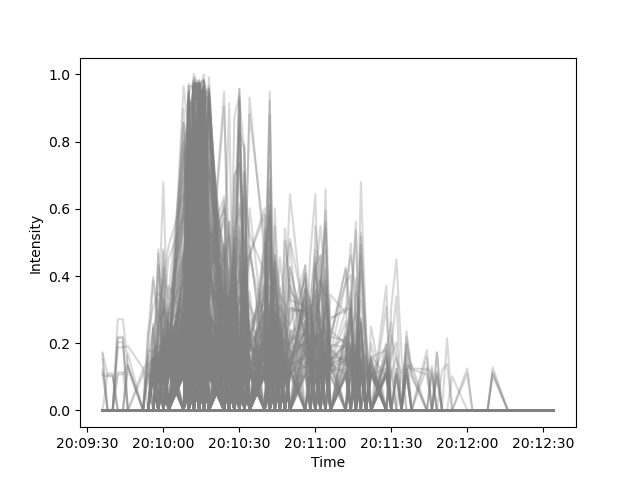

In [51]:
fig4 = plt.figure()
ax4 = fig4.add_subplot(111)
for n in range(count_10):
    ax4.plot(euitimes, norm_intensity_10[n,], color = 'gray', alpha = 0.3)
#ax4.plot(euitimes, average_intensity_10, color = 'red')
ax4.set_xlabel("Time")
ax4.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove curves with more than one peak above 0.3</h3>

In [52]:
single_peak_10 = []
for n in range(count_10):
    peaks = scipy.signal.find_peaks(norm_intensity_10[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_10.append(norm_intensity_10[n])

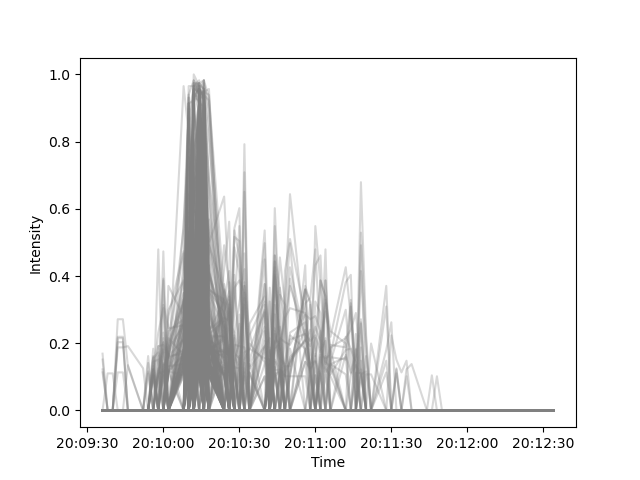

In [53]:
fig5 = plt.figure()
ax5 = fig5.add_subplot(111)
for n in range(len(single_peak_10)):
    ax5.plot(euitimes, single_peak_10[n], color = 'gray', alpha = 0.3)
ax5.set_xlabel("Time")
ax5.set_ylabel("Intensity")
#ax5.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they all peak at the same time</h3>

In [54]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_10 = []

In [55]:
for n in range(len(single_peak_10)):
    peak = scipy.signal.find_peaks(single_peak_10[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_10.append(euitimes - deltat)

In [56]:
flare_times = []
for n in range(15):
    flare_times.append(datetime(2024, 4, 5, 19, 59, (2*n)+30, 00000))
for n in range(15):
    flare_times.append(datetime(2024, 4, 5, 20, 00, 2*n, 00000))
flare_times.append(datetime(2024, 4, 5, 20, 00, 30, 00000))
#flare_times

In [57]:
average_intensity_10 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_10)):
        for m in range(len(euitimes_shifted_10[n])):
            if euitimes_shifted_10[n][m].hour == flare_times[k].hour and euitimes_shifted_10[n][m].minute == flare_times[k].minute and euitimes_shifted_10[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_10[k] = average_intensity_10[k] + single_peak_10[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_10[k] = average_intensity_10[k]/count

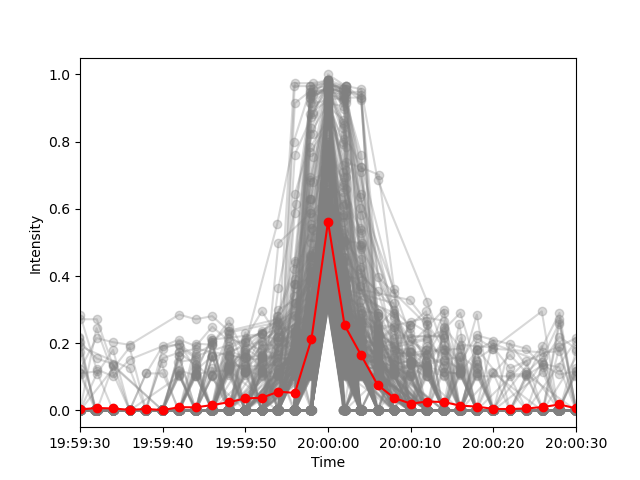

In [58]:
figz = plt.figure()
axz = figz.add_subplot(111)
for n in range(len(single_peak_10)):
    axz.plot(euitimes_shifted_10[n], single_peak_10[n], color = 'gray', alpha = 0.3, marker = 'o')
axz.plot(flare_times, average_intensity_10, 'r-o')
axz.set_xlabel("Time")
axz.set_ylabel("Intensity")
axz.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/Decay from Average Intensity</h3>

In [59]:
X = np.zeros(len(flare_times))
for n in range(15):
    X[n] = flare_times[n].second
for n in range(16):
    X[n+15] = flare_times[n+15].second + 60
# for n in range(22):
#     X[n+32] = euitimes[n+32].second + 120
# for n in range(14):
#     X[n+54] = euitimes[n+54].second + 180
X

array([30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50., 52., 54.,
       56., 58., 60., 62., 64., 66., 68., 70., 72., 74., 76., 78., 80.,
       82., 84., 86., 88., 90.])

In [60]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_10)
results_half = scipy.signal.peak_widths(average_intensity_10, peak, rel_height=0.5)
results_half

(array([1.68349969, 0.89329825, 0.51354231, 0.60047438, 1.70425258,
        1.66481346, 1.26215332]),
 array([0.00502653, 0.00293004, 0.00932594, 0.05390576, 0.28277544,
        0.0232293 , 0.01187623]),
 array([ 0.5       ,  3.5       ,  5.98645769, 11.89952562, 14.20131646,
        20.5       , 28.23784668]),
 array([ 2.18349969,  4.39329825,  6.5       , 12.5       , 15.90556904,
        22.16481346, 29.5       ]))

In [61]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_10)

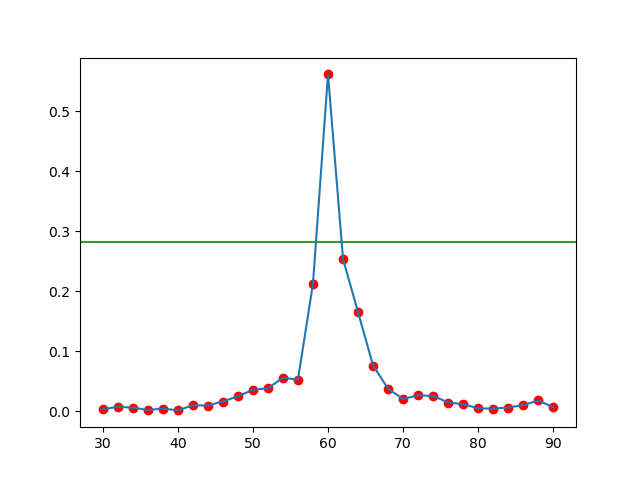

In [62]:
figk = plt.figure()
axk = figk.add_subplot(111)
axk.plot(X, average_intensity_10, 'ro')
axk.axhline(0.28277544, color="C2")
axk.plot(xnew, ynew)
plt.show()

In [63]:
ynew.max()

np.float64(0.5615602883861638)

In [64]:
ynew[500]

np.float64(0.5615602883861638)

In [65]:
ynew[530]

np.float64(0.28448990317202744)

In [66]:
xnew[530]

np.float64(61.8)

<h2>20% threshold</h2>

<h3>Apply threshold</h3>

In [67]:
threshold = 0.2*max.max()
initial_masked_20 = short_exposure_map_seq[0]
xdim = int(initial_masked_20.dimensions[0].value)
ydim = int(initial_masked_20.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if initial_masked_20.data[i,j] < threshold:
            initial_masked_20.data[i,j] = 0

In [68]:
second_masked_20 = short_exposure_map_seq[1]
xdim = int(second_masked_20.dimensions[0].value)
ydim = int(second_masked_20.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if second_masked_20.data[i,j] < threshold:
            second_masked_20.data[i,j] = 0

In [69]:
masked_map_seq_20 = sunpy.map.Map([initial_masked_20, second_masked_20], sequence = True)

In [70]:
for n in range(65):
    next_map = short_exposure_map_seq[2+n]
    xdim = int(next_map.dimensions[0].value)
    ydim = int(next_map.dimensions[1].value)
    for i in range(ydim):
        for j in range(xdim):
            if next_map.data[i,j] < threshold:
                next_map.data[i,j] = 0
    masked_map_seq_20 = sunpy.map.Map(masked_map_seq_20.maps + [next_map], sequence = True)

<h3>Apply watershed segmentation</h3>

In [71]:
labels_20 = []
for n in range(67):
    index = n
    image = masked_map_seq_20[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    labels_20.append(labels)

<h3>Identify which pixels have kernels</h3>

In [72]:
pixels_20 = np.zeros([559, 472])
for n in range(67):
    next_label = labels_20[n]
    xdim = int(next_label.shape[0])
    ydim = int(next_label.shape[1])
    for i in range(xdim):
        for j in range(ydim):
            if next_label[i,j] != 0:
                pixels_20[i,j] = 1

<h3>Extract lightcurves for each pixel</h3>

In [73]:
count = 0
for i in range(pixels_20.shape[0]):
    for j in range(pixels_20.shape[1]):
        if pixels_20[i,j] != 0:
            count = count + 1
count_20 = count
print(count)

698


In [74]:
intensity_20 = np.zeros([count_20, 68])

In [75]:
m = 0 
for i in range(pixels_20.shape[0]):
    for j in range(pixels_20.shape[1]):
        if pixels_20[i,j] != 0:
            for n in range(67):
                intensity_20[m,n] = short_exposure_map_seq[n].data[i,j]
            m = m + 1

In [76]:
norm_intensity_20 = intensity_20/(intensity_20.max())

<h3>Plot pixel lightcurves</h3>

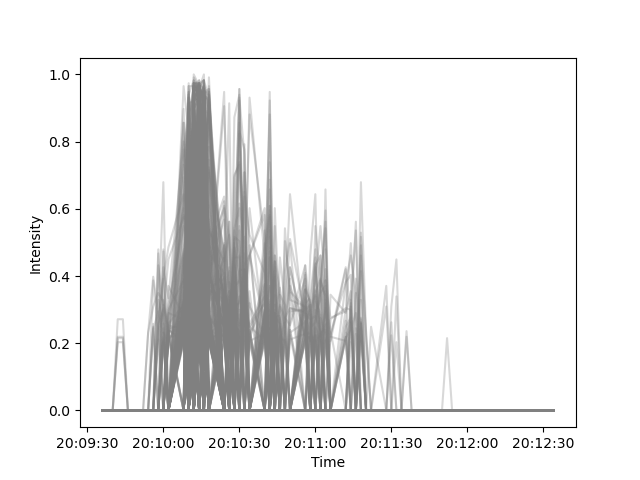

In [77]:
fig7 = plt.figure()
ax7 = fig7.add_subplot(111)
for n in range(count_20):
    ax7.plot(euitimes, norm_intensity_20[n,], color = 'gray', alpha = 0.3)
#ax4.plot(euitimes, average_intensity_10, color = 'red')
ax7.set_xlabel("Time")
ax7.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove lightcurves with more than one peak above 0.3</h3>

In [78]:
single_peak_20 = []
for n in range(count_20):
    peaks = scipy.signal.find_peaks(norm_intensity_20[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_20.append(norm_intensity_20[n])

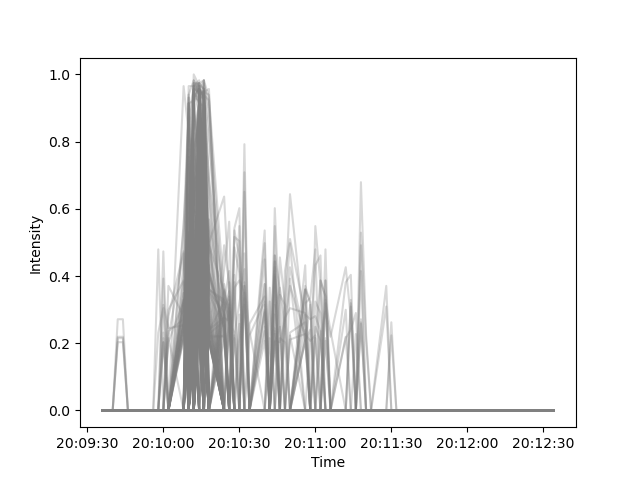

In [79]:
fig8 = plt.figure()
ax8 = fig8.add_subplot(111)
for n in range(len(single_peak_20)):
    ax8.plot(euitimes, single_peak_20[n], color = 'gray', alpha = 0.3)
ax8.set_xlabel("Time")
ax8.set_ylabel("Intensity")
#ax8.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they all peak at the same time</h3>

In [80]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_20 = []

In [81]:
for n in range(len(single_peak_20)):
    peak = scipy.signal.find_peaks(single_peak_20[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_20.append(euitimes - deltat)

In [82]:
average_intensity_20 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_20)):
        for m in range(len(euitimes_shifted_20[n])):
            if euitimes_shifted_20[n][m].hour == flare_times[k].hour and euitimes_shifted_20[n][m].minute == flare_times[k].minute and euitimes_shifted_20[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_20[k] = average_intensity_20[k] + single_peak_20[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_20[k] = average_intensity_20[k]/count

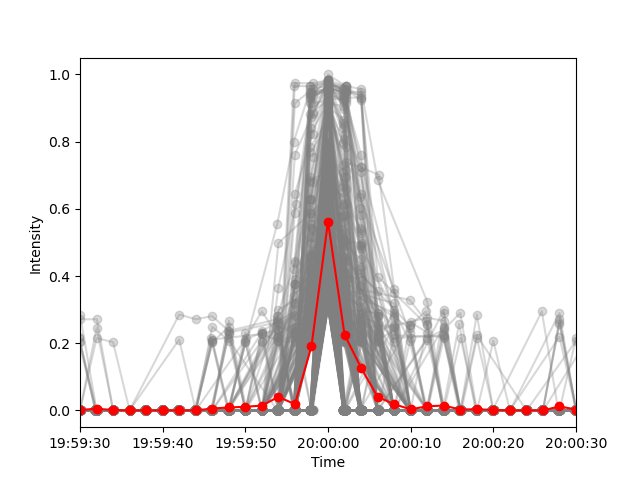

In [83]:
fig9 = plt.figure()
ax9 = fig9.add_subplot(111)
for n in range(len(single_peak_20)):
    ax9.plot(euitimes_shifted_20[n], single_peak_20[n], color = 'gray', alpha = 0.3, marker = 'o')
ax9.plot(flare_times, average_intensity_20, 'r-o')
ax9.set_xlabel("Time")
ax9.set_ylabel("Intensity")
ax9.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Gaussian Process Regression</h3>

In [84]:
y = average_intensity_20
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

In [85]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X.reshape(-1, 1), y)
gaussian_process.kernel_

0.111**2 * RBF(length_scale=1.71)

In [86]:
mean_prediction, std_prediction = gaussian_process.predict(X.reshape(-1, 1), return_std=True)

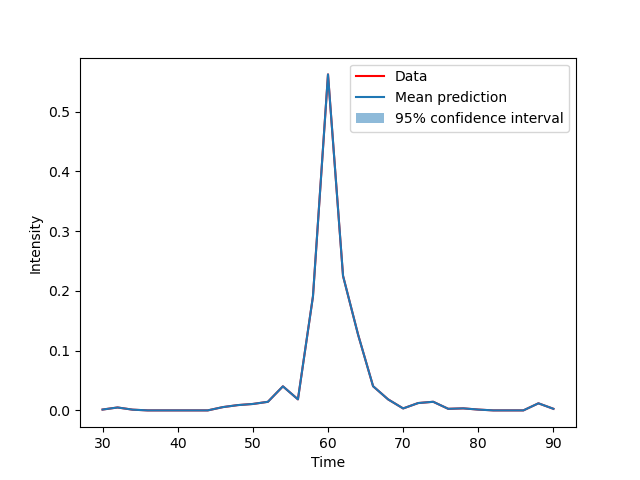

In [87]:
figh = plt.figure()
axh = figh.add_subplot(111)
# for n in range(len(single_peak_20)):
#     axh.plot(euitimes_shifted_20[n], single_peak_20[n], color = 'gray', alpha = 0.3, marker = 'o')
#axh.plot(flare_times, average_intensity_20, 'r-o')
axh.plot(X, average_intensity_20, 'r', label='Data')
#axh.plot(X, y)
axh.plot(X, mean_prediction, label="Mean prediction")
axh.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
axh.set_xlabel("Time")
axh.set_ylabel("Intensity")
#axh.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
axh.legend()
plt.show()

<h3>Rise/Decay from Average Intensity</h3>

In [88]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_20)
results_half = scipy.signal.peak_widths(average_intensity_20, peak, rel_height=0.5)
results_half

(array([0.97498035, 0.91983644, 1.59096932, 1.85569481, 0.68755922,
        0.88844035]),
 array([0.00313556, 0.02936612, 0.28109291, 0.00883195, 0.00301354,
        0.00722959]),
 array([ 0.5       , 11.58016356, 14.24298963, 20.61763256, 23.5       ,
        28.61155965]),
 array([ 1.47498035, 12.5       , 15.83395894, 22.47332738, 24.18755922,
        29.5       ]))

In [89]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_20)

In [90]:
#manually find where the peak and rise/decaying FWHMs are

In [91]:
ynew.max()

np.float64(0.5621858295833986)

In [92]:
ynew[500]

np.float64(0.5621858295833986)

In [93]:
ynew[475]

np.float64(0.2836960040792164)

In [94]:
ynew[527]

np.float64(0.28916847960536524)

In [95]:
xnew[475]

np.float64(58.5)

In [96]:
xnew[500]

np.float64(60.0)

In [97]:
xnew[527]

np.float64(61.62)

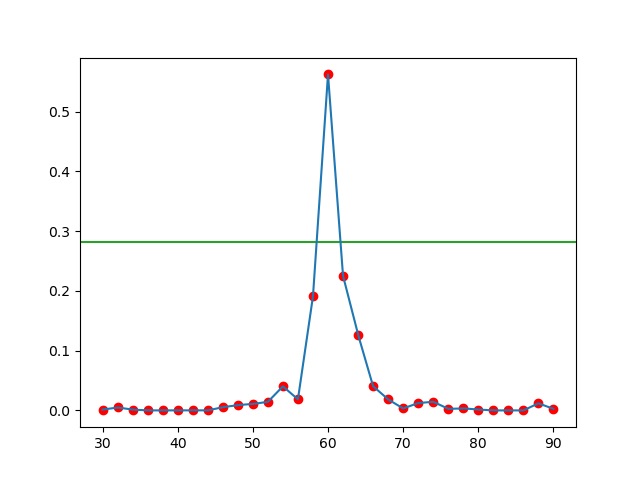

In [98]:
figj = plt.figure()
axj = figj.add_subplot(111)
axj.plot(X, average_intensity_20, 'ro')
#axj.plot(peaks, average_intensity_20[peaks], "x")
axj.axhline(0.28109291, color="C2")
axj.plot(xnew, ynew)
plt.show()

<h2>30% Threshold</h2>

<h3>Apply threshold</h3>

In [99]:
threshold = 0.3*max.max()
initial_masked_30 = short_exposure_map_seq[0]
xdim = int(initial_masked_30.dimensions[0].value)
ydim = int(initial_masked_30.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if initial_masked_30.data[i,j] < threshold:
            initial_masked_30.data[i,j] = 0

In [100]:
second_masked_30 = short_exposure_map_seq[1]
xdim = int(second_masked_30.dimensions[0].value)
ydim = int(second_masked_30.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if second_masked_30.data[i,j] < threshold:
            second_masked_30.data[i,j] = 0

In [101]:
masked_map_seq_30 = sunpy.map.Map([initial_masked_30, second_masked_30], sequence = True)

In [102]:
for n in range(65):
    next_map = short_exposure_map_seq[2+n]
    xdim = int(next_map.dimensions[0].value)
    ydim = int(next_map.dimensions[1].value)
    for i in range(ydim):
        for j in range(xdim):
            if next_map.data[i,j] < threshold:
                next_map.data[i,j] = 0
    masked_map_seq_30 = sunpy.map.Map(masked_map_seq_30.maps + [next_map], sequence = True)

<h3>Apply watershed segmentation</h3>

In [103]:
labels_30 = []
for n in range(67):
    index = n
    image = masked_map_seq_30[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    labels_30.append(labels)

<h3>Identify which pixels are in kernels</h3>

In [104]:
pixels_30 = np.zeros([559, 472])
for n in range(67):
    next_label = labels_30[n]
    xdim = int(next_label.shape[0])
    ydim = int(next_label.shape[1])
    for i in range(xdim):
        for j in range(ydim):
            if next_label[i,j] != 0:
                pixels_30[i,j] = 1

<h3>Extract lightcurves for each pixel</h3>

In [105]:
count = 0
for i in range(pixels_30.shape[0]):
    for j in range(pixels_30.shape[1]):
        if pixels_30[i,j] != 0:
            count = count + 1
count_30 = count
print(count)

475


In [106]:
intensity_30 = np.zeros([count_30, 68])

In [107]:
m = 0 
for i in range(pixels_30.shape[0]):
    for j in range(pixels_30.shape[1]):
        if pixels_30[i,j] != 0:
            for n in range(67):
                intensity_30[m,n] = short_exposure_map_seq[n].data[i,j]
            m = m + 1

In [108]:
norm_intensity_30 = intensity_30/(intensity_30.max())

<h3>Plot pixel lightcurves</h3>

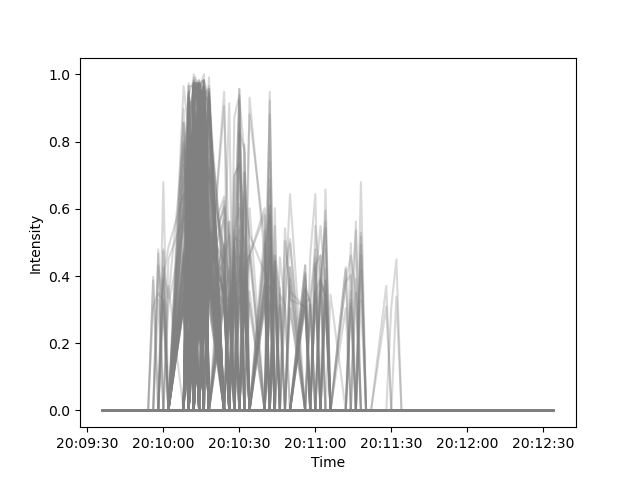

In [109]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
for n in range(count_30):
    ax1.plot(euitimes, norm_intensity_30[n,], color = 'gray', alpha = 0.3)
ax1.set_xlabel("Time")
ax1.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove lightcurves with more than one peak above 0.3</h3>

In [110]:
single_peak_30 = []
for n in range(count_30):
    peaks = scipy.signal.find_peaks(norm_intensity_30[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_30.append(norm_intensity_30[n])

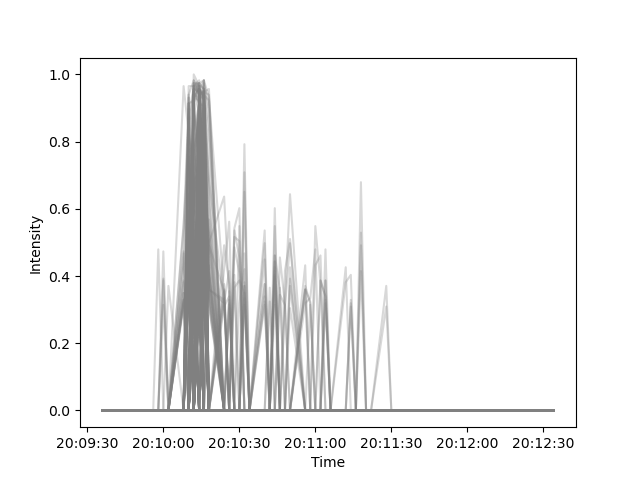

In [111]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
for n in range(len(single_peak_30)):
    ax2.plot(euitimes, single_peak_30[n], color = 'gray', alpha = 0.3)
ax2.set_xlabel("Time")
ax2.set_ylabel("Intensity")
#ax2.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they all peak at the same time</h3>

In [112]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_30 = []

In [113]:
for n in range(len(single_peak_30)):
    peak = scipy.signal.find_peaks(single_peak_30[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_30.append(euitimes - deltat)

In [114]:
average_intensity_30 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_30)):
        for m in range(len(euitimes_shifted_30[n])):
            if euitimes_shifted_30[n][m].hour == flare_times[k].hour and euitimes_shifted_30[n][m].minute == flare_times[k].minute and euitimes_shifted_30[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_30[k] = average_intensity_30[k] + single_peak_30[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_30[k] = average_intensity_30[k]/count

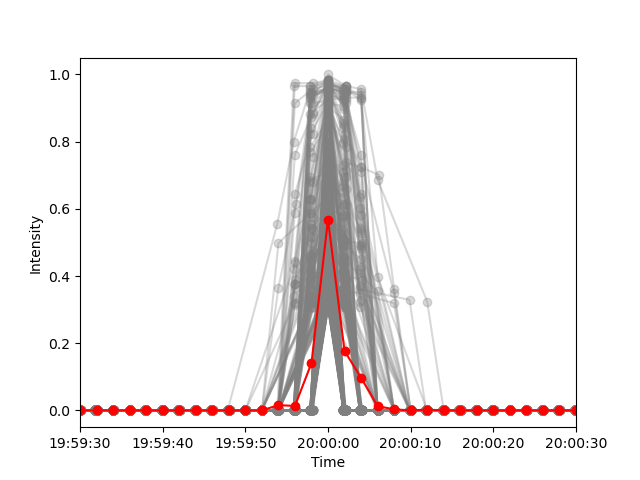

In [115]:
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
for n in range(len(single_peak_30)):
    ax3.plot(euitimes_shifted_30[n], single_peak_30[n], color = 'gray', alpha = 0.3, marker = 'o')
ax3.plot(flare_times, average_intensity_30, 'r-o')
ax3.set_xlabel("Time")
ax3.set_ylabel("Intensity")
ax3.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

<h3>Rise/Decay from Average Intensity</h3>

In [116]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_30)
results_half = scipy.signal.peak_widths(average_intensity_30, peak, rel_height=0.5)
results_half

(array([0.57953735, 1.39047467, 1.        ]),
 array([0.01444308, 0.2839844 , 0.00117399]),
 array([11.92046265, 14.33539086, 20.5       ]),
 array([12.5       , 15.72586553, 21.5       ]))

In [117]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_30)

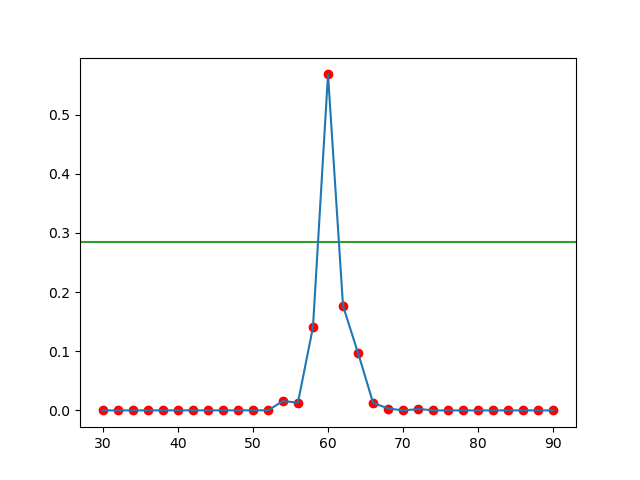

In [118]:
figm = plt.figure()
axm = figm.add_subplot(111)
axm.plot(X, average_intensity_30, 'ro')
axm.axhline(0.2839844, color="C2")
axm.plot(xnew, ynew)
plt.show()

In [119]:
ynew.max()

np.float64(0.567968805748599)

In [120]:
ynew[500]

np.float64(0.567968805748599)

In [121]:
xnew[478]

np.float64(58.68)

In [122]:
xnew[524]

np.float64(61.44)

<h2>50% threshold</h2>

<h3>Apply threshold</h3>

In [123]:
threshold = 0.5*max.max()
initial_masked_50 = short_exposure_map_seq[0]
xdim = int(initial_masked_50.dimensions[0].value)
ydim = int(initial_masked_50.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if initial_masked_50.data[i,j] < threshold:
            initial_masked_50.data[i,j] = 0

In [124]:
second_masked_50 = short_exposure_map_seq[1]
xdim = int(second_masked_50.dimensions[0].value)
ydim = int(second_masked_50.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if second_masked_50.data[i,j] < threshold:
            second_masked_50.data[i,j] = 0

In [125]:
masked_map_seq_50 = sunpy.map.Map([initial_masked_50, second_masked_50], sequence = True)

In [126]:
for n in range(65):
    next_map = short_exposure_map_seq[2+n]
    xdim = int(next_map.dimensions[0].value)
    ydim = int(next_map.dimensions[1].value)
    for i in range(ydim):
        for j in range(xdim):
            if next_map.data[i,j] < threshold:
                next_map.data[i,j] = 0
    masked_map_seq_50 = sunpy.map.Map(masked_map_seq_50.maps + [next_map], sequence = True)

<h3>Apply watershed segmentation</h3>

In [127]:
labels_50 = []
for n in range(67):
    index = n
    image = masked_map_seq_50[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    labels_50.append(labels)

<h3>Identify which pixels are in kernels</h3>

In [128]:
pixels_50 = np.zeros([559, 472])
for n in range(67):
    next_label = labels_50[n]
    xdim = int(next_label.shape[0])
    ydim = int(next_label.shape[1])
    for i in range(xdim):
        for j in range(ydim):
            if next_label[i,j] != 0:
                pixels_50[i,j] = 1

<h3>Extract lightcurves for each pixel</h3>

In [129]:
count = 0
for i in range(pixels_50.shape[0]):
    for j in range(pixels_50.shape[1]):
        if pixels_50[i,j] != 0:
            count = count + 1
count_50 = count
print(count)

263


In [130]:
intensity_50 = np.zeros([count_50, 68])

In [131]:
m = 0 
for i in range(pixels_50.shape[0]):
    for j in range(pixels_50.shape[1]):
        if pixels_50[i,j] != 0:
            for n in range(67):
                intensity_50[m,n] = short_exposure_map_seq[n].data[i,j]
            m = m + 1

In [132]:
norm_intensity_50 = intensity_50/(intensity_50.max())

<h3>Plot pixel lightcurves</h3>

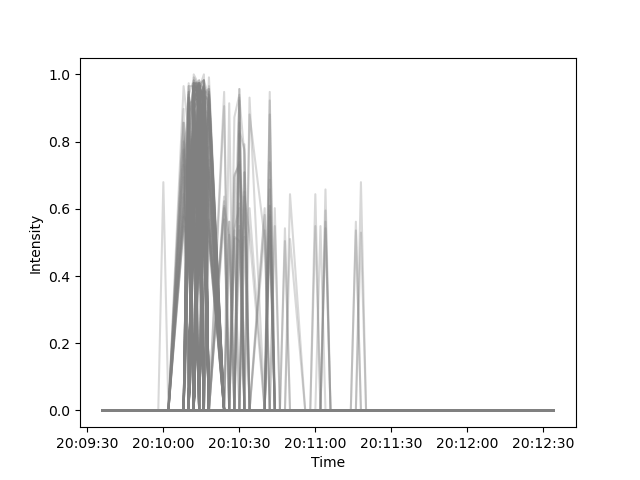

In [133]:
figa = plt.figure()
axa = figa.add_subplot(111)
for n in range(count_50):
    axa.plot(euitimes, norm_intensity_50[n,], color = 'gray', alpha = 0.3)
axa.set_xlabel("Time")
axa.set_ylabel("Intensity")
#ax4.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Remove lightcurves with more than one peak above 0.3</h3>

In [134]:
single_peak_50 = []
for n in range(count_50):
    peaks = scipy.signal.find_peaks(norm_intensity_50[n], height = 0.3)
    if peaks[0].shape[0] == 1:
        single_peak_50.append(norm_intensity_50[n])

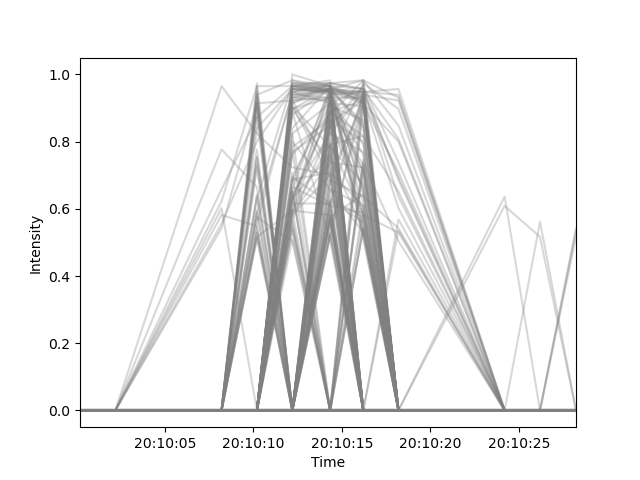

In [135]:
figb = plt.figure()
axb = figb.add_subplot(111)
for n in range(len(single_peak_50)):
    axb.plot(euitimes, single_peak_50[n], color = 'gray', alpha = 0.3)
axb.set_xlabel("Time")
axb.set_ylabel("Intensity")
axb.set_xlim(euitimes[10], euitimes[20])
plt.show()

<h3>Align curves so they all peak at the same time</h3>

In [136]:
shift_peak_time = datetime(2024, 4, 5, 20, 00, 00, 00000)
euitimes_shifted_50 = []

In [137]:
for n in range(len(single_peak_50)):
    peak = scipy.signal.find_peaks(single_peak_50[n], height = 0.3)[0][0]
    deltat = euitimes[peak] - shift_peak_time
    euitimes_shifted_50.append(euitimes - deltat)

In [138]:
average_intensity_50 = np.zeros(len(flare_times))
for k in range(len(flare_times)):
    count = 0
    for n in range(len(euitimes_shifted_50)):
        for m in range(len(euitimes_shifted_50[n])):
            if euitimes_shifted_50[n][m].hour == flare_times[k].hour and euitimes_shifted_50[n][m].minute == flare_times[k].minute and euitimes_shifted_50[n][m].second == flare_times[k].second:
                #print(flare_times[k])
                #print(euitimes_shifted[n][m])
                average_intensity_50[k] = average_intensity_50[k] + single_peak_50[n][m]
                #print(average_intensity_10[k])
                count = count + 1
    average_intensity_50[k] = average_intensity_50[k]/count

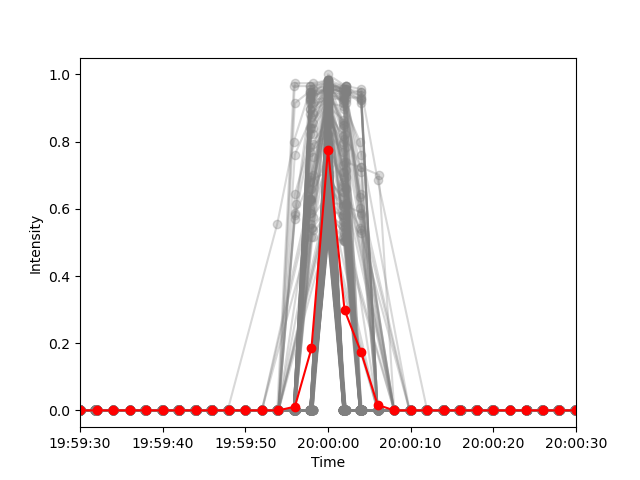

In [139]:
figc = plt.figure()
axc = figc.add_subplot(111)
for n in range(len(single_peak_50)):
    axc.plot(euitimes_shifted_50[n], single_peak_50[n], color = 'gray', alpha = 0.3, marker = 'o')
axc.plot(flare_times, average_intensity_50, 'r-o')
axc.set_xlabel("Time")
axc.set_ylabel("Intensity")
axc.set_xlim([datetime(2024, 4, 5, 19, 59, 30, 00000), datetime(2024, 4, 5, 20, 00, 30, 00000)])
plt.show()

In [140]:
#determine peaks then determine FWHM of peaks
#second array outputted gives the intensity values of the FWHM
peak, _ = scipy.signal.find_peaks(average_intensity_50)
results_half = scipy.signal.peak_widths(average_intensity_50, peak, rel_height=0.5)
results_half

(array([1.46885745]),
 array([0.38823422]),
 array([14.3439433]),
 array([15.81280075]))

In [141]:
#interpolate average intensity points
xnew = np.linspace(30, 90, 1001)
ynew = np.interp(xnew, X, average_intensity_50)

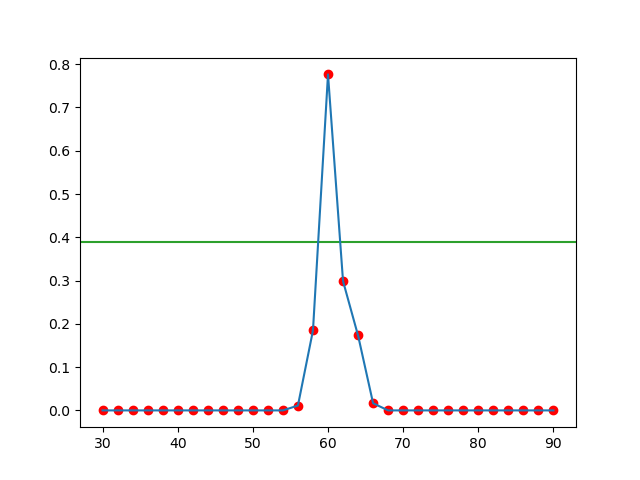

In [142]:
fign = plt.figure()
axn = fign.add_subplot(111)
axn.plot(X, average_intensity_50, 'ro')
axn.axhline(0.38823422, color="C2")
axn.plot(xnew, ynew)
plt.show()

In [143]:
ynew.max()

np.float64(0.7764684479113341)

In [144]:
ynew[500]

np.float64(0.7764684479113341)

In [145]:
xnew[478]

np.float64(58.68)

In [146]:
xnew[527]

np.float64(61.62)

<h2>Rise and Decay Times</h2>

| Threshold | FWHM rise time | Max Intensity | FWHM decay time | $t_{rise}$ | $t_{decay}$ |
| :- | :-: | :-: | :-: | :-: | :-: |
| $10\%$ | 58.44 | 60 | 61.80 | 1.56 | 1.80 |
| $20\%$ | 58.50 | 60 | 61.62 | 1.50 | 1.62 |
| $30\%$ | 58.68 | 60 | 61.44 | 1.32 | 1.44 |
| $50\%$ | 58.68 | 60 | 61.62 | 1.32 | 1.62 |